<a href="https://colab.research.google.com/github/shinra-a/collab/blob/main/%D0%9B%D0%A0_%E2%84%961_Python_%D0%B8_%D0%B2%D0%B8%D0%B7%D1%83%D0%B0%D0%BB%D0%B8%D0%BB%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%B3%D0%BE%D1%82%D0%BE%D0%B2%D0%BE%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №1. Python и визуалилизация данных#
#### Заполните код в клетках (где написано "Ваш код здесь")

In [ ]:
import numpy as np
import pandas as pd
%matplotlib inline

In [ ]:
Считайте данные из файла titanic_train.csv в память в виде объекта Pandas.DataFrame

In [7]:
df = pd.read_csv('/titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##### 1. Сколько мужчин / женщин находилось на борту?

Напишите код и правильный вариант ответа

1) 412 мужчин и 479 женщин

2) 314 мужчин и 577 женщин

3) 479 мужчин и 412 женщин

4) 577 мужчин и 314 женщин

In [8]:
df['Sex'].value_counts()


,count
Sex,
male,577
female,314


**Правильный ответ 4.**

---



#####  2. Выведите распределение переменной Pclass (социально-экономический статус) и это же распределение, только для мужчин / женщин по отдельности. Сколько было мужчин 2-го класса?

Напишите код и правильный вариант ответа

1) 104

2) 108

3) 112

4) 125

In [12]:
df['Pclass'].value_counts()


108

In [13]:
df.groupby('Sex')['Pclass'].value_counts()

Sex     Pclass
female  3         144
        1          94
        2          76
male    3         347
        1         122
        2         108
Name: count, dtype: int64

In [14]:
len(df[(df['Sex'] == 'male') & (df['Pclass'] == 2)])

108

#####  3. Каковы медиана и стандартное отклонение платежей (Fare)?

Напишите код и правильный вариант ответа

1) Медиана – 14.45, стандартное отклонение – 49.69

2) Медиана – 15.1, стандартное отклонение – 12.15

3) Медиана – 13.15, стандартное отклонение – 35.3

4) Медиана – 17.43, стандартное отклонение – 39.1

In [16]:
fare_median = df['Fare'].median()
fare_std = df['Fare'].std()

print(f"Медиана: {fare_median}")
print(f"Стандартное отклонение: {fare_std}")


Медиана: 14.4542
Стандартное отклонение: 49.693428597180905


Правильный ответ 1.

---




##### 4. Правда ли, что люди моложе 30 лет выживали чаще, чем люди старше 60 лет? Каковы доли выживших в обеих группах?

Напишите код и правильный вариант ответа

1) 22.7% среди молодых и 40.6% среди старых

2) 40.6% среди молодых и 22.7% среди старых

3) 35.3% среди молодых и 27.4% среди старых

4) 27.4% среди молодых и 35.3% среди старых

In [25]:
young_survived = df[df['Age'] < 30]['Survived'].mean()
old_survived = df[df['Age'] > 60]['Survived'].mean()

print(f"{young_survived * 100:.1f}% среди молодых и {old_survived * 100:.1f}% среди старых")



40.6% среди молодых и 22.7% среди старых


**Правильный ответ 2**

---



##### 5. Правда ли, что женщины выживали чаще мужчин? Каковы доли выживших в обеих группах?

Напишите код и правильный вариант ответа

1) 30.2% среди мужчин и 46.2% среди женщин

2) 35.7% среди мужчин и 74.2% среди женщин

3) 21.1% среди мужчин и 46.2% среди женщин

4) 18.9% среди мужчин и 74.2% среди женщин


In [33]:
male = df[df['Sex'] == 'male']['Survived'].mean()
fmale = df[df['Sex'] == 'female']['Survived'].mean()
print(f"{male * 100:.1f}% среди мужчин и {fmale * 100:.1f}% среди женщин")

18.9% среди мужчин и 74.2% среди женщин


**Правильный ответ 4**

---



##### 6. Сравните графически распределение стоимости билетов и возраста у спасенных и у погибших. Средний возраст погибших выше, верно?

Напишите код и правильный вариант ответа

1) Да

2) Нет


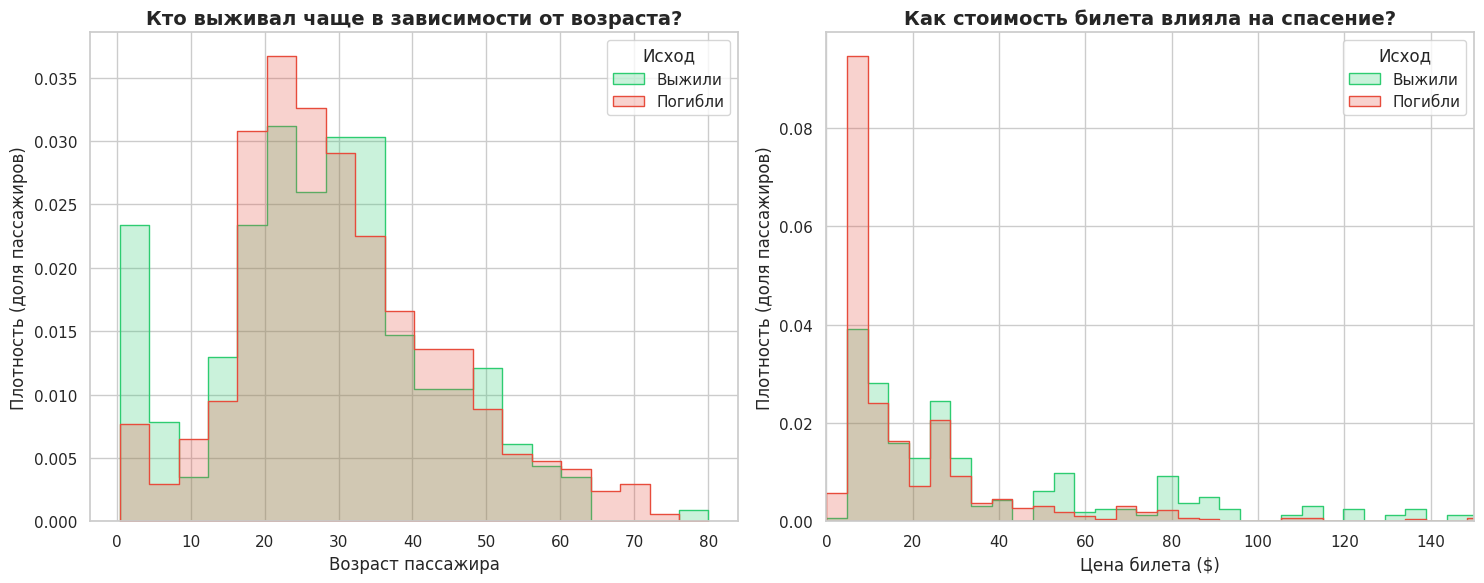

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем стиль графиков
sns.set_theme(style="whitegrid", palette="muted")

# Создаем сетку строка колонки, и присваиваем их в массив графиков axes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. График распределения ВОЗРАСТА, нормализирован(считается плотность) по значениям чтобы не было сырых
#    цифр так как сравнивать их в абсолютных числах муторно
sns.histplot(
    data=df, x='Age', hue='Survived',
    #kde=True,
    element="step", stat="density", common_norm=False,
    ax=axes[0], palette=['#e74c3c', '#2ecc71']
)
axes[0].set_title('Кто выживал чаще в зависимости от возраста?', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Возраст пассажира', fontsize=12)
axes[0].set_ylabel('Плотность (доля пассажиров)', fontsize=12)
axes[0].legend(title='Исход', labels=['Выжили', 'Погибли']) # Меняем легенду на понятный язык

# 2. График распределения СТОИМОСТИ БИЛЕТОВ
sns.histplot(
    data=df, x='Fare', hue='Survived',
    #kde=True,
    element="step", stat="density", common_norm=False,
    ax=axes[1], palette=['#e74c3c', '#2ecc71']
)
axes[1].set_title('Как стоимость билета влияла на спасение?', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Цена билета ($)', fontsize=12)
axes[1].set_ylabel('Плотность (доля пассажиров)', fontsize=12)
axes[1].set_xlim(0, 150) # Ограничим цену до 150$, чтобы убрать пустой хвост дорогих билетов
axes[1].legend(title='Исход', labels=['Выжили', 'Погибли'])

# Автоматически выравниваем отступы, чтобы подписи не налезали друг на друга
plt.tight_layout()
plt.show()




##### 7. Как отличается средний возраст мужчин / женщин в зависимости от класса обслуживания? Выберите верные утверждения:

Напишите код и правильный вариант ответа

1) В среднем мужчины 1-го класса старше 40 лет

2) В среднем женщины 1-го класса старше 40 лет

3) Мужчины всех классов в среднем старше женщин того же класса

4) В среднем люди в 1 классе старше, чем во 2-ом, а те старше представителей 3-го класса

In [47]:
# Базовые переменные для удобства проверок
m1 = df[df['Sex'] == 'male']['Age'].mean()
w1 = df[df['Sex'] == 'female']['Age'].mean()

# Считаем общий средний возраст по классам
c1 = df[df['Pclass'] == 1]['Age'].mean()
c2 = df[df['Pclass'] == 2]['Age'].mean()
c3 = df[df['Pclass'] == 3]['Age'].mean()

# Проверяем, что мужчины старше женщин во всех классах (все 3 условия должны быть True)
m_older_w = (df.groupby(['Pclass', 'Sex'])['Age'].mean().unstack().eval('male > female')).all()

#  словарь
statements = {
    "1. В среднем мужчины 1-го класса старше 40 лет": m1 > 40,
    "2. В среднем женщины 1-го класса старше 40 лет": w1 > 40,
    "3. Мужчины всех классов в среднем старше женщин того же класса": m_older_w,
    "4. В среднем люди в 1 классе старше, чем во 2-ом, а те старше 3-го": c1 > c2 > c3
}

# Вывод каждого пункта
for text, is_true in statements.items():
    status = "TRUE" if is_true else "FALSE"
    print(f"{text} -> {status}")


1. В среднем мужчины 1-го класса старше 40 лет -> FALSE
2. В среднем женщины 1-го класса старше 40 лет -> FALSE
3. Мужчины всех классов в среднем старше женщин того же класса -> TRUE
4. В среднем люди в 1 классе старше, чем во 2-ом, а те старше 3-го -> TRUE


##### 8. Постройте попарные зависимости признаков Age, Fare, Pclass, Sex, SibSp, Parch, Embarked и Survived. (метод scatter_matrix Pandas или pairplot Seaborn).

Напишите код и визуализируйте

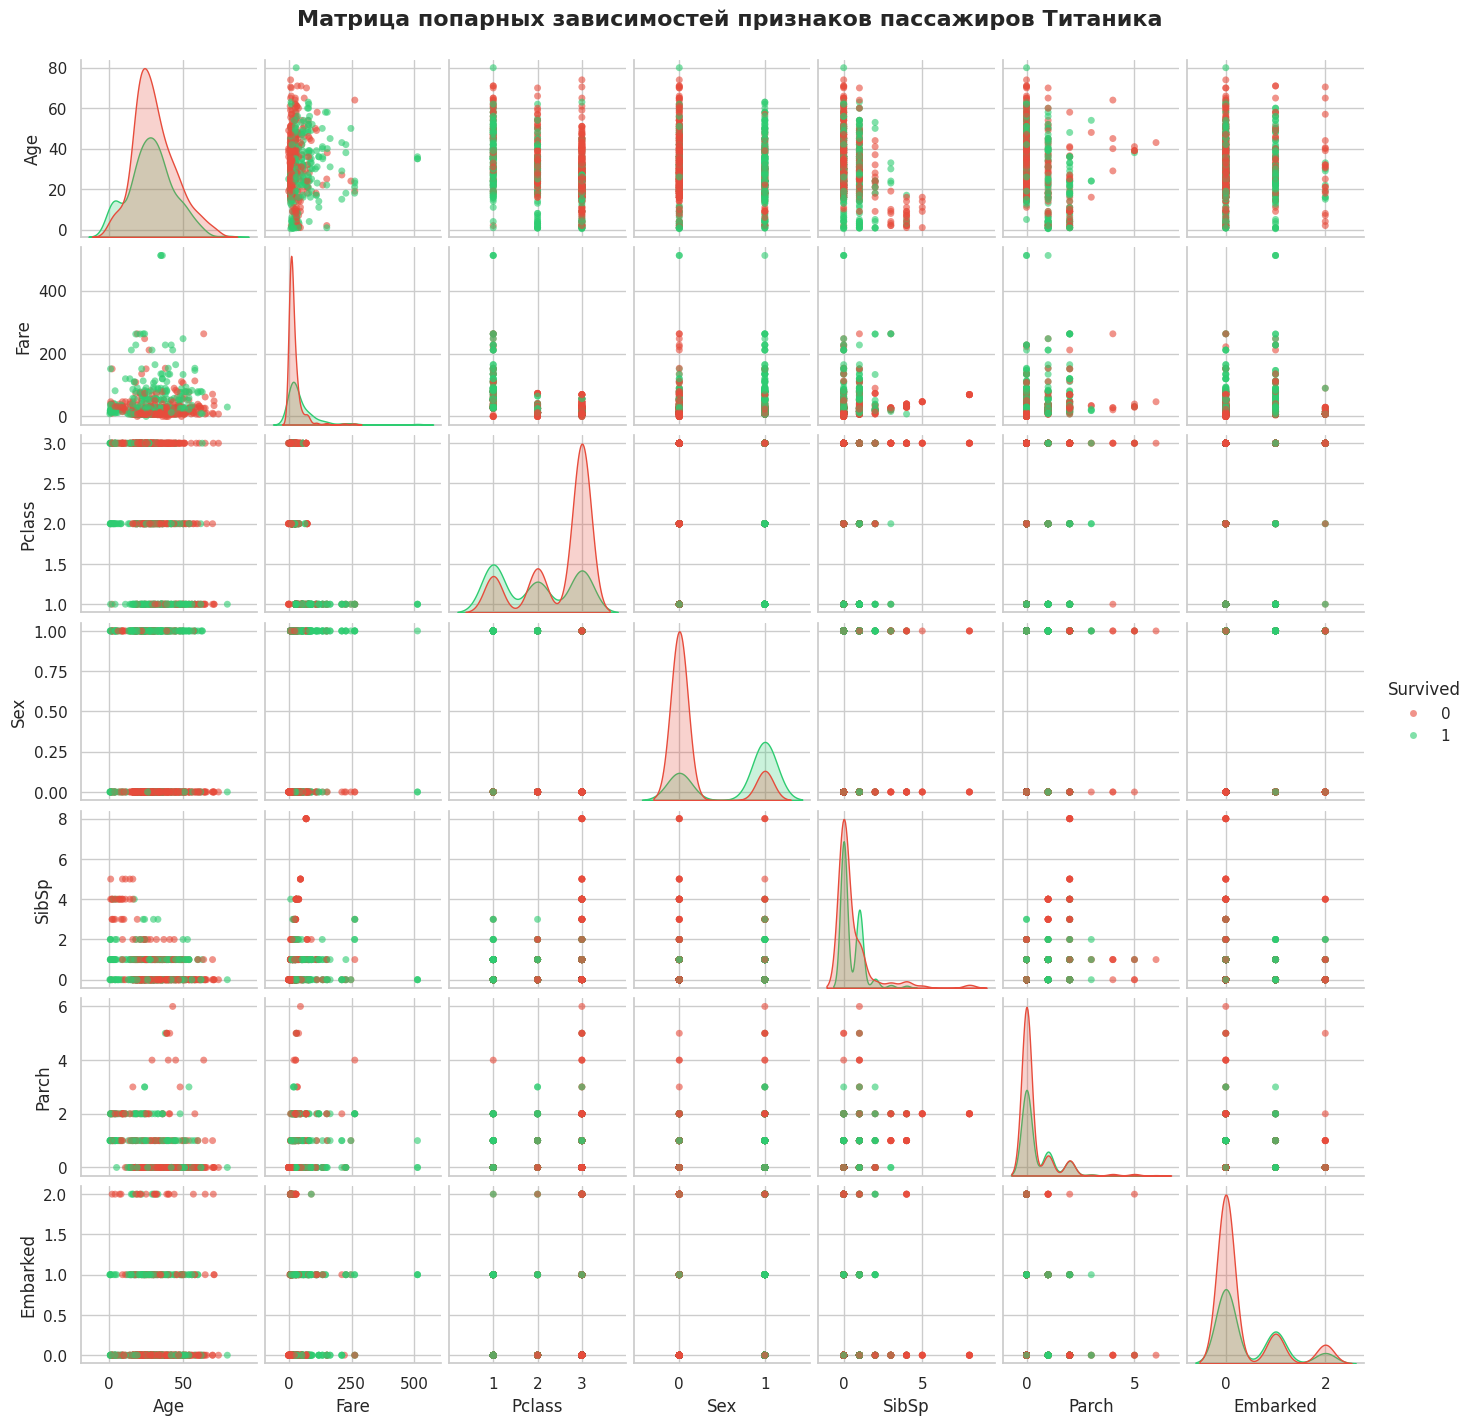

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Готовим данные: отбираем нужные колонки
features = ['Age', 'Fare', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'Survived']
df_pair = df[features].copy()

# 2. Переводим текст в числа, чтобы pairplot смог их нормально построить
df_pair['Sex'] = df_pair['Sex'].map({'male': 0, 'female': 1})
df_pair['Embarked'] = df_pair['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 3. Настраиваем общий красивый стиль
sns.set_theme(style="whitegrid")

# 4. Строим мега-график pairplot
# hue='Survived' разделит точки по выживаемости
# palette задает наши фирменные цвета: красный (0 - погиб) и зеленый (1 - выжил)
g = sns.pairplot(
    df_pair,
    hue='Survived',
    palette=['#e74c3c', '#2ecc71'],
    diag_kind='kde',  # На диагонали делаем сглаженные графики плотности
    plot_kws={'alpha': 0.6, 's': 25, 'edgecolor': 'none'}, # Делаем точки слегка прозрачными, чтобы они не сливались
    height=2.0        # Размер каждого маленького графика
)

# 5. Красиво подписываем общую картину
g.fig.suptitle('Матрица попарных зависимостей признаков пассажиров Титаника', y=1.02, fontsize=16, fontweight='bold')

plt.show()


##### 9. Как плата за билет (Fare) зависит от класса каюты (Pclass)? Постройте boxplot.

Напишите код и визуализируйте

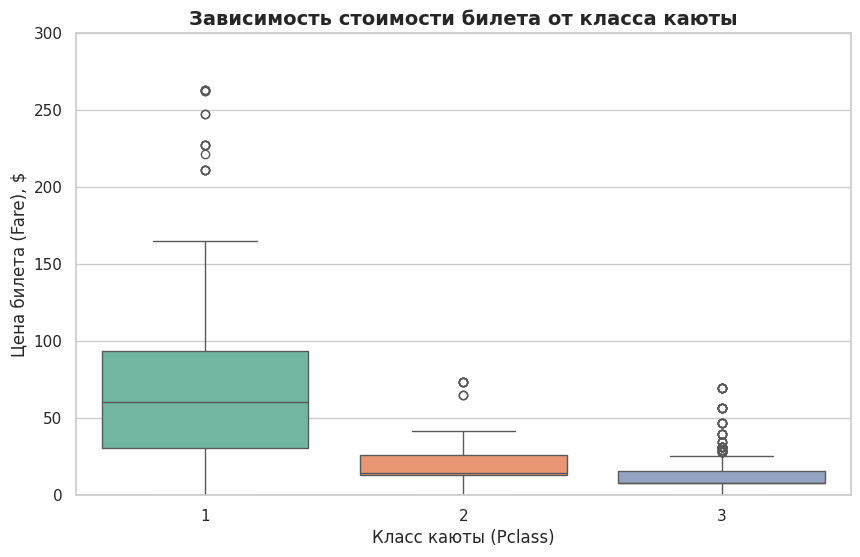

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем стиль
sns.set_theme(style="whitegrid")

# Создаем холст для графика
plt.figure(figsize=(10, 6))

#Строим Boxplot
#hue='Pclass' и legend=False нужны, чтобы каждый класс покрасился в свой цвет без предупреждений
sns.boxplot(x='Pclass', y='Fare', hue='Pclass', data=df, palette='Set2', legend=False)

# Делаем график понятным для человека
plt.title('Зависимость стоимости билета от класса каюты', fontsize=14, fontweight='bold')
plt.xlabel('Класс каюты (Pclass)', fontsize=12)
plt.ylabel('Цена билета (Fare), $', fontsize=12)

#Ограничиваем ось Y, чтобы выбросы не ломали масштаб
plt.ylim(0,300)
plt.show()


##### 10. Каково соотношение погибших и выживших в зависимости от пола? Отобразите c помощью Seaborn.countplot c аргументом hue.

Напишите код и визуализируйте

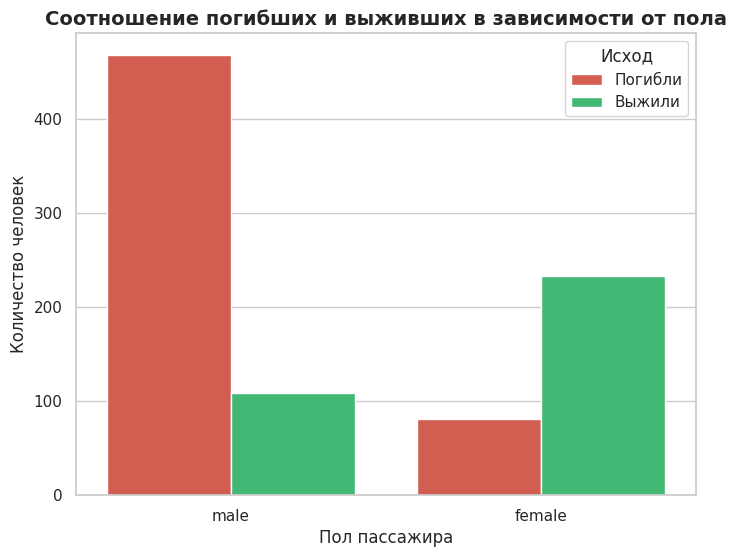

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем стиль
sns.set_theme(style="whitegrid")

# Создаем холст для графика
plt.figure(figsize=(8, 6))

# Строим countplot
# x='Sex' — делим по полу на две группы
# hue='Survived' — внутри каждой группы разделяем на выживших/погибших
sns.countplot(x='Sex', hue='Survived', data=df, palette=['#e74c3c', '#2ecc71'])


plt.title('Соотношение погибших и выживших в зависимости от пола', fontsize=14, fontweight='bold')
plt.xlabel('Пол пассажира', fontsize=12)
plt.ylabel('Количество человек', fontsize=12)

# Переименовываем подписи в легенде, чтобы вместо 0 и 1 был понятный текст
plt.legend(title='Исход', labels=['Погибли', 'Выжили'])

plt.show()


##### 11. Каково соотношение погибших и выживших в зависимости от класса каюты? Отобразите c помощью Seaborn.countplot c аргументом hue.

Напишите код и визуализируйте

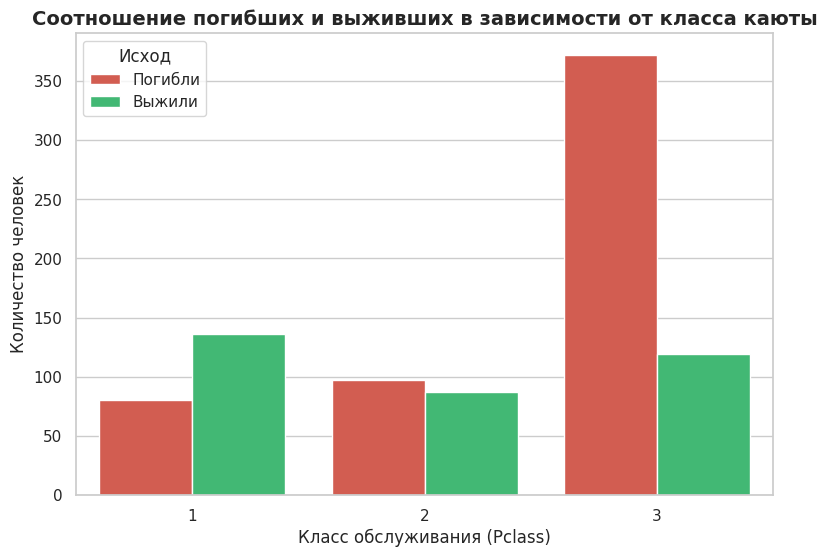

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем стиль
sns.set_theme(style="whitegrid")

# Создаем холст для графика
plt.figure(figsize=(9, 6))

# Строим countplot
# x='Pclass' — делим по классам на три группы (1, 2, 3)
# hue='Survived' — внутри каждой группы разделяем на выживших/погибших
sns.countplot(x='Pclass', hue='Survived', data=df, palette=['#e74c3c', '#2ecc71'])

plt.title('Соотношение погибших и выживших в зависимости от класса каюты', fontsize=14, fontweight='bold')
plt.xlabel('Класс обслуживания (Pclass)', fontsize=12)
plt.ylabel('Количество человек', fontsize=12)

# Переименовываем подписи в легенде, чтобы вместо 0 и 1 был понятный текст
plt.legend(title='Исход', labels=['Погибли', 'Выжили'])

plt.show()


##### 12. Как факт выживания зависит от возраста пассажира? Проверьте (графически) предположение, что молодые чаще выживали. Пусть, условно, молодые - младше 30 лет, пожилые – старше 60 лет.

Напишите код и визуализируйте

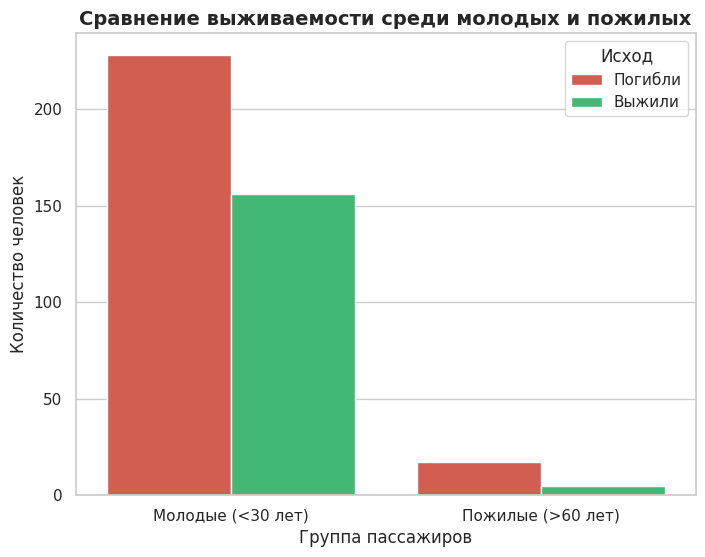

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Создаем временный датасет только с нужными нам группами
df_groups = df.dropna(subset=['Age']).copy()

def get_age_group(age):
    if age < 30:
        return 'Молодые (<30 лет)'
    elif age > 60:
        return 'Пожилые (>60 лет)'
    return None

df_groups['Возрастная группа'] = df_groups['Age'].apply(get_age_group)
df_filtered = df_groups[df_groups['Возрастная группа'].notna()]

# 2. Настраиваем и строим понятный график
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Строим countplot, где по X идут наши две группы, а hue делит на выживших/погибших
sns.countplot(
    x='Возрастная группа',
    hue='Survived',
    data=df_filtered,
    palette=['#e74c3c', '#2ecc71'],
    order=['Молодые (<30 лет)', 'Пожилые (>60 лет)']
)

plt.title('Сравнение выживаемости среди молодых и пожилых', fontsize=14, fontweight='bold')
plt.xlabel('Группа пассажиров', fontsize=12)
plt.ylabel('Количество человек', fontsize=12)
plt.legend(title='Исход', labels=['Погибли', 'Выжили'])

plt.show()
